# Caracterización Acústica y Discriminación Multivariante de Géneros Musicales
## Modelos Lineales Robustos y Análisis Espacial Discriminante
---
**Dataset**: Spotify Tracks · 5 géneros × 1 000 registros · 9 características acústicas

In [1]:
# LIBRERÍAS
# ──────────────────────────────────────────────────────────────────────────────
import warnings, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, yeojohnson, f as f_dist, chi2

from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import confusion_matrix, classification_report

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.multivariate.manova import MANOVA

import pingouin as pg

from IPython.display import display, Markdown

In [3]:
# CONFIGURACIÓN GLOBAL DE GRÁFICOS (calidad de publicación)
# ──────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Segoe UI", "DejaVu Sans"],
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "text.color": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
})

PALETTE_5 = {"Clásica": "#f1c40f", "EDM": "#e74c3c", "Hip-Hop": "#3498db",
             "K-Pop": "#e056a0", "Metal": "#8e44ad"}
GENRE_ORDER = list(PALETTE_5.keys())

---
## 1 · Preprocesamiento y Exploración Analítica (EDA)

In [4]:
# 1.1  CARGA Y FILTRADO
# ──────────────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("dataset_1.csv", index_col=0)

generos_sel = ["classical", "edm", "hip-hop", "k-pop", "metal"]
df = df_raw[df_raw["track_genre"].isin(generos_sel)].copy()
print(f"Registros seleccionados: {df.shape[0]}  ({df['track_genre'].value_counts().to_dict()})")

Registros seleccionados: 5000  ({'classical': 1000, 'edm': 1000, 'hip-hop': 1000, 'k-pop': 1000, 'metal': 1000})


In [5]:
# 1.2  PURGA DE DUPLICADOS
# ──────────────────────────────────────────────────────────────────────────────
n_antes = len(df)
df.drop_duplicates(subset="track_id", inplace=True)
print(f"Duplicados eliminados: {n_antes - len(df)}  →  Registros finales: {len(df)}")

Duplicados eliminados: 140  →  Registros finales: 4860


In [6]:
# 1.3  RENOMBRADO DE VARIABLES AL ESPAÑOL
# ──────────────────────────────────────────────────────────────────────────────
RENAME_MAP = {
    "danceability": "bailabilidad",
    "energy": "energía",
    "loudness": "volumen",
    "speechiness": "habla",
    "acousticness": "acusticidad",
    "instrumentalness": "instrumentalidad",
    "liveness": "vivacidad",
    "valence": "valencia",
    "tempo": "tempo",
    "track_genre": "género",
}
df.rename(columns=RENAME_MAP, inplace=True)

# Mapear nombres de géneros al español
GENRE_MAP = {"classical": "Clásica", "edm": "EDM", "hip-hop": "Hip-Hop",
             "k-pop": "K-Pop", "metal": "Metal"}
df["género"] = df["género"].map(GENRE_MAP)

VARS_ACUSTICAS = ["bailabilidad", "energía", "volumen", "habla",
                  "acusticidad", "instrumentalidad", "vivacidad",
                  "valencia", "tempo"]

print("Variables acústicas:", VARS_ACUSTICAS)
display(df[VARS_ACUSTICAS + ["género"]].head())

Variables acústicas: ['bailabilidad', 'energía', 'volumen', 'habla', 'acusticidad', 'instrumentalidad', 'vivacidad', 'valencia', 'tempo']


,bailabilidad,energía,volumen,habla,acusticidad,instrumentalidad,vivacidad,valencia,tempo,género
16000,0.643,0.268,-15.073,0.0900,0.593,0.000002,0.316,0.620,143.813,Clásica
16001,0.484,0.898,-4.132,0.1640,0.365,0.000000,0.091,0.680,91.975,Clásica
16002,0.608,0.638,-6.008,0.0292,0.581,0.017200,0.448,0.439,140.109,Clásica
16003,0.695,0.293,-16.278,0.0431,0.596,0.015800,0.132,0.637,143.804,Clásica
16004,0.583,0.308,-18.303,0.0465,0.581,0.010600,0.257,0.241,118.226,Clásica


In [7]:
# 1.4  ESTANDARIZACIÓN Z-SCORE
# ──────────────────────────────────────────────────────────────────────────────
scaler = StandardScaler()
df_z = df.copy()
df_z[VARS_ACUSTICAS] = scaler.fit_transform(df[VARS_ACUSTICAS])
display(Markdown("**Estandarización Z-score aplicada** — media ≈ 0, σ ≈ 1 para las 9 variables."))
display(df_z[VARS_ACUSTICAS].describe().round(4).T[["mean", "std"]])

**Estandarización Z-score aplicada** — media ≈ 0, σ ≈ 1 para las 9 variables.

,mean,std
bailabilidad,0.0,1.0001
energía,-0.0,1.0001
volumen,-0.0,1.0001
habla,0.0,1.0001
acusticidad,0.0,1.0001
instrumentalidad,0.0,1.0001
vivacidad,-0.0,1.0001
valencia,-0.0,1.0001
tempo,0.0,1.0001


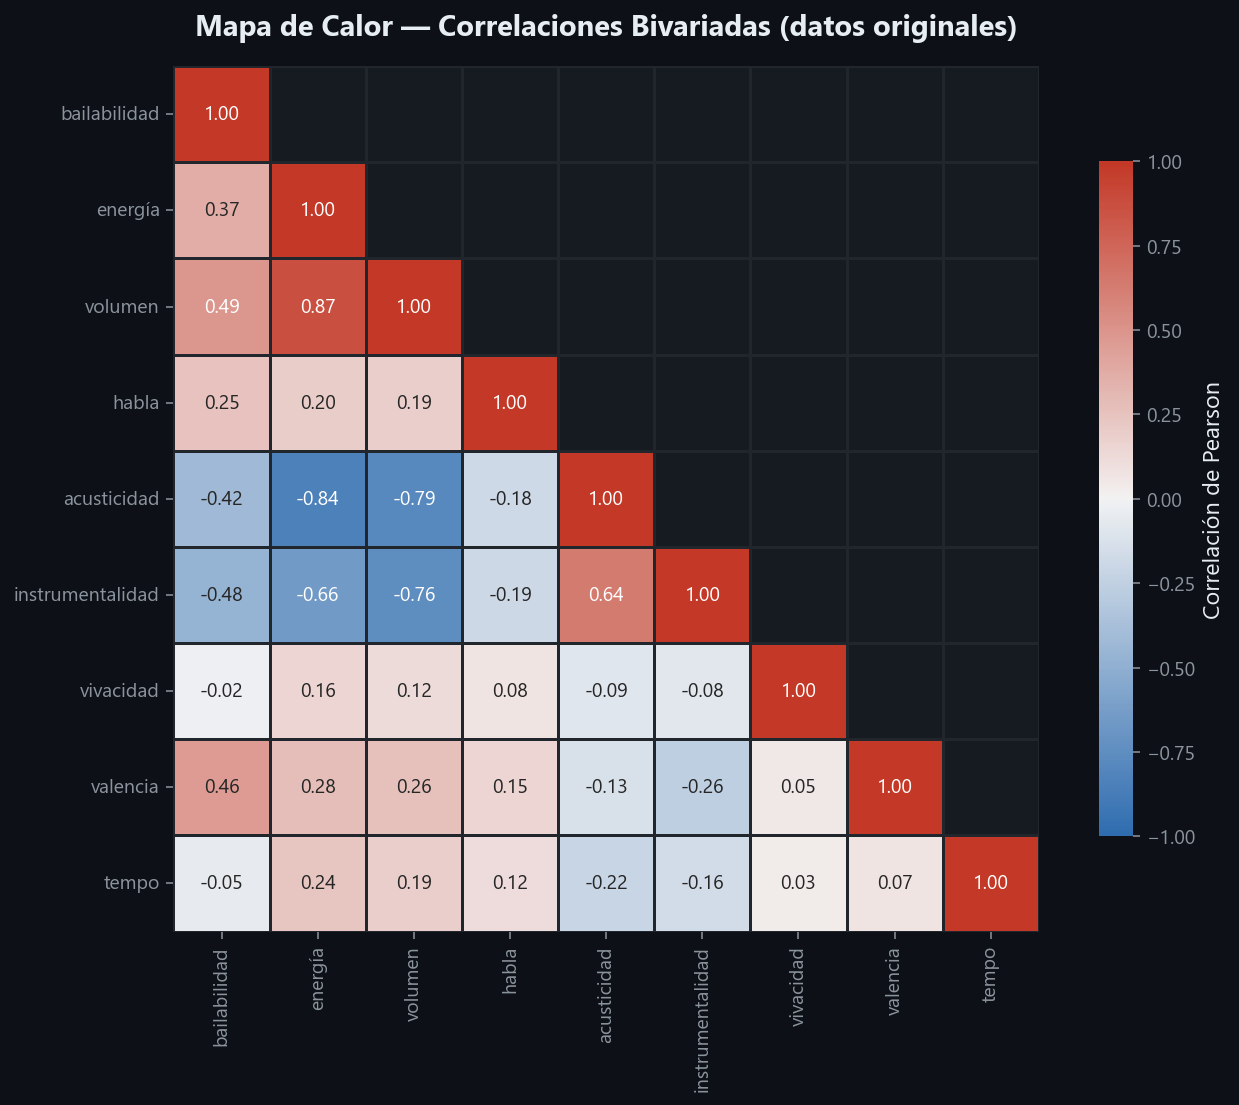

In [8]:
# 1.5  GRÁFICO — Heatmap de Correlaciones
# ──────────────────────────────────────────────────────────────────────────────
corr = df[VARS_ACUSTICAS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(250, 15, s=85, l=45, n=12, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            vmin=-1, vmax=1, linewidths=.6, linecolor="#21262d",
            cbar_kws={"shrink": .78, "label": "Correlación de Pearson"},
            square=True, ax=ax)
ax.set_title("Mapa de Calor — Correlaciones Bivariadas (datos originales)",
             fontsize=15, fontweight="bold", pad=16, color="#e6edf3")
plt.tight_layout()
plt.show()

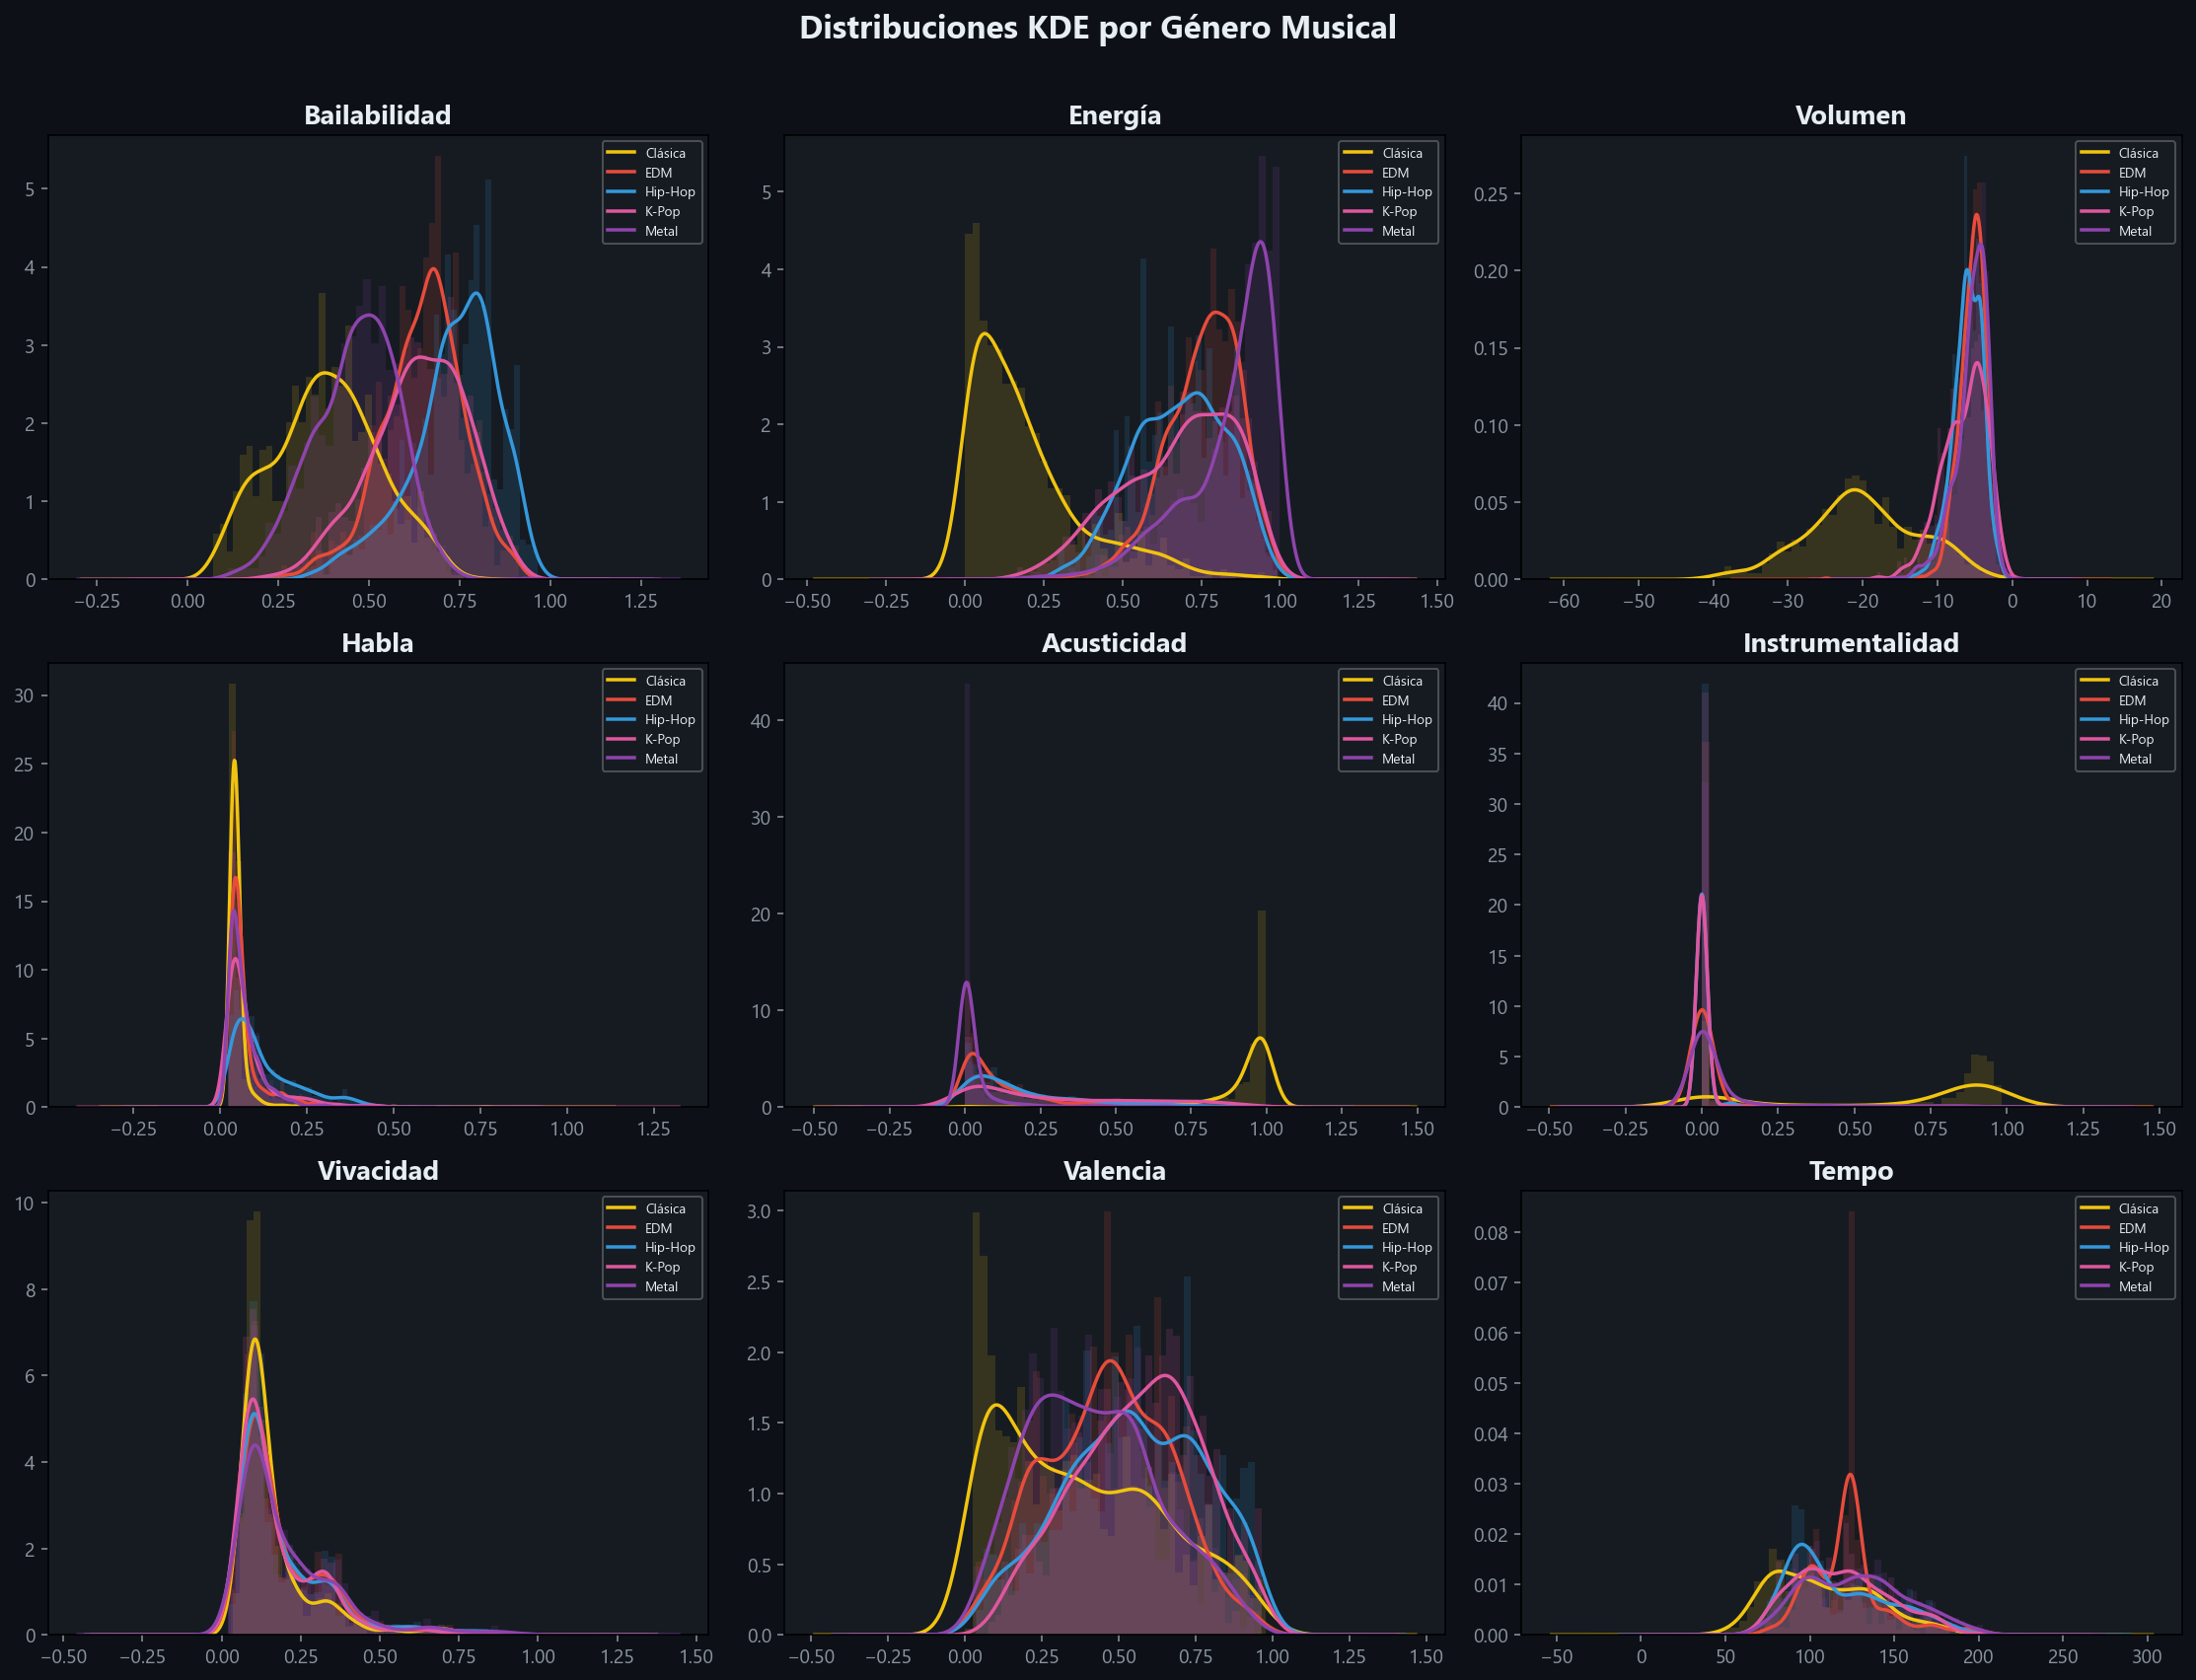

In [9]:
# 1.6  GRÁFICO — Densidades KDE Solapadas por Género
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, var in zip(axes.ravel(), VARS_ACUSTICAS):
    for gen in GENRE_ORDER:
        subset = df.loc[df["género"] == gen, var].dropna()
        ax.hist(subset, bins=40, density=True, alpha=0.15,
                color=PALETTE_5[gen], edgecolor="none")
        subset.plot.kde(ax=ax, color=PALETTE_5[gen], lw=1.8, label=gen)
    ax.set_title(var.capitalize(), fontweight="bold", color="#e6edf3")
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.legend(fontsize=7, framealpha=0.3)

fig.suptitle("Distribuciones KDE por Género Musical", fontsize=17,
             fontweight="bold", y=1.01, color="#e6edf3")
plt.tight_layout()
plt.show()

---
## 2 · Modelamiento Predictivo Univariante y Diagnóstico de Supuestos

In [10]:
# 2.1  FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
# ──────────────────────────────────────────────────────────────────────────────
PREDICTORES = [v for v in VARS_ACUSTICAS if v != "energía"]
X_vif = sm.add_constant(df[PREDICTORES].dropna())

vif_data = pd.DataFrame({
    "Variable": PREDICTORES,
    "VIF": [variance_inflation_factor(X_vif.values, i+1) for i in range(len(PREDICTORES))]
}).sort_values("VIF", ascending=False)

display(Markdown("### Factor de Inflación de la Varianza (VIF)"))
display(Markdown("Umbral habitual: VIF > 10 → multicolinealidad severa"))
display(vif_data.style.format({"VIF": "{:.2f}"}).hide(axis="index"))

### Factor de Inflación de la Varianza (VIF)

Umbral habitual: VIF > 10 → multicolinealidad severa

Variable,VIF
volumen,3.83
acusticidad,2.82
instrumentalidad,2.46
bailabilidad,1.78
valencia,1.35
tempo,1.12
habla,1.10
vivacidad,1.03


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.2  FASE 1 — MODELO OLS BASE CON ENERGÍA CRUDA (sin transformación)
# ──────────────────────────────────────────────────────────────────────────────
df_model = df[PREDICTORES + ["energía"]].dropna().copy()
y_crudo = df_model["energía"].values
X_ols = sm.add_constant(df_model[PREDICTORES])

modelo_base = sm.OLS(y_crudo, X_ols).fit()

display(Markdown("### Fase 1 — Modelo OLS Base (energía SIN transformar)"))
print(modelo_base.summary())


### Fase 1 — Modelo OLS Base (energía SIN transformar)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.845
Method:                 Least Squares   F-statistic:                     3304.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:33:52   Log-Likelihood:                 3975.7
No. Observations:                4860   AIC:                            -7933.
Df Residuals:                    4851   BIC:                            -7875.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.9377      0.011  

In [46]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.3  DIAGNÓSTICO DE NORMALIDAD — RESIDUOS DEL MODELO BASE
# ──────────────────────────────────────────────────────────────────────────────
residuos_base = modelo_base.resid

# Shapiro-Wilk (máx 5000 observaciones)
stat_sw_base, p_sw_base = shapiro(residuos_base[:5000])

display(Markdown(textwrap.dedent(f"""
### Prueba de Shapiro-Wilk — Residuos del Modelo Base (energía cruda)

| Elemento | Valor |
|----------|-------|
| **H₀** | Los residuos siguen una distribución normal |
| **Estadístico W** | {stat_sw_base:.4f} |
| **P-valor** | {p_sw_base:.6f} |
| **Decisión** | {"✅ No se rechaza H₀ (α = 0.05) → normalidad aceptable" if p_sw_base > 0.05 else "❌ Se rechaza H₀ → los residuos NO son normales. Se requiere transformación."} |
""")))



### Prueba de Shapiro-Wilk — Residuos del Modelo Base (energía cruda)

| Elemento | Valor |
|----------|-------|
| **H₀** | Los residuos siguen una distribución normal |
| **Estadístico W** | 0.9974 |
| **P-valor** | 0.000000 |
| **Decisión** | ❌ Se rechaza H₀ → los residuos NO son normales. Se requiere transformación. |


In [47]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.5  DIAGNÓSTICO DE HETEROCEDASTICIDAD — BREUSCH-PAGAN
# ──────────────────────────────────────────────────────────────────────────────
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(modelo_yj.resid, modelo_yj.model.exog)

display(Markdown(textwrap.dedent(f"""
### Prueba de Breusch-Pagan (Homocedasticidad)

| Elemento | Valor |
|----------|-------|
| **H₀** | La varianza de los residuos es constante (homocedasticidad) |
| **Estadístico LM** | {bp_stat:.4f} |
| **P-valor (LM)** | {bp_p:.6f} |
| **Estadístico F** | {bp_f:.4f} |
| **P-valor (F)** | {bp_fp:.6f} |
| **Decisión** | {"✅ No se rechaza H₀ → homocedasticidad aceptable" if bp_p > 0.05 else "❌ Se rechaza H₀ → heterocedasticidad presente — se requiere corrección HC3"} |
""")))



### Prueba de Breusch-Pagan (Homocedasticidad)

| Elemento | Valor |
|----------|-------|
| **H₀** | La varianza de los residuos es constante (homocedasticidad) |
| **Estadístico LM** | 262.9331 |
| **P-valor (LM)** | 0.000000 |
| **Estadístico F** | 34.6821 |
| **P-valor (F)** | 0.000000 |
| **Decisión** | ❌ Se rechaza H₀ → heterocedasticidad presente — se requiere corrección HC3 |


In [48]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.3  EVALUACIÓN DE TRANSFORMACIONES SOBRE LA VARIABLE DEPENDIENTE
# ──────────────────────────────────────────────────────────────────────────────
from scipy.stats import shapiro, yeojohnson, boxcox

y_raw = df_model["energía"].values

# ── Diccionario de transformaciones ──
transformaciones = {}

# 1) Sin transformación
transformaciones["Sin transformar"] = y_raw.copy()

# 2) Yeo-Johnson (acepta ceros y negativos)
y_yj, lmbda_yj = yeojohnson(y_raw)
transformaciones["Yeo-Johnson"] = y_yj

# 3) Box-Cox (requiere valores estrictamente positivos)
y_pos = y_raw.copy()
y_pos[y_pos <= 0] = 1e-10  # reemplazar ceros/negativos
y_bc, lmbda_bc = boxcox(y_pos)
transformaciones["Box-Cox"] = y_bc

# 4) Logaritmo natural (requiere positivos)
transformaciones["Log (ln)"] = np.log(y_pos)

# 5) Raíz cuadrada
transformaciones["Raíz cuadrada"] = np.sqrt(y_pos)

# 6) Inversa (1/x)
transformaciones["Inversa (1/x)"] = 1.0 / (y_pos + 1e-10)

# ── Evaluar cada transformación: OLS → residuos → Shapiro-Wilk ──
resultados = []
modelos_transf = {}

for nombre, y_t in transformaciones.items():
    modelo_t = sm.OLS(y_t, X_ols).fit()
    residuos_t = modelo_t.resid
    stat_w, p_val = shapiro(residuos_t[:5000])
    
    modelos_transf[nombre] = {"modelo": modelo_t, "y": y_t}
    resultados.append({
        "Transformación": nombre,
        "λ": lmbda_yj if nombre == "Yeo-Johnson" else (lmbda_bc if nombre == "Box-Cox" else "—"),
        "W (Shapiro)": stat_w,
        "P-valor": p_val,
        "R²": modelo_t.rsquared,
        "Normal (α=0.05)": "✅ Sí" if p_val > 0.05 else "❌ No"
    })

df_resultados = pd.DataFrame(resultados).sort_values("P-valor", ascending=False)

display(Markdown("### Comparación de Transformaciones — Shapiro-Wilk sobre Residuos"))
display(Markdown("La **mejor transformación** es la que tiene el **p-valor más alto** (más cercano a normalidad)."))
display(df_resultados.style
        .format({"W (Shapiro)": "{:.6f}", "P-valor": "{:.6f}", "R²": "{:.4f}"})
        .highlight_max(subset=["P-valor"], color="#2ea04370")
        .hide(axis="index"))

# ── Seleccionar la mejor ──
mejor = df_resultados.iloc[0]
mejor_nombre = mejor["Transformación"]

display(Markdown(textwrap.dedent(f"""
### 🏆 Mejor Transformación: **{mejor_nombre}**

| Métrica | Valor |
|---------|-------|
| **Shapiro-Wilk W** | {mejor["W (Shapiro)"]:.6f} |
| **P-valor** | {mejor["P-valor"]:.6f} |
| **R²** | {mejor["R²"]:.4f} |
| **¿Normalidad?** | {mejor["Normal (α=0.05)"]} |

> Esta transformación se usará en el **Modelo Definitivo**.
""")))

# ── Guardar para usar en el modelo definitivo ──
y_transf = modelos_transf[mejor_nombre]["y"]
modelo_yj = modelos_transf[mejor_nombre]["modelo"]


### Comparación de Transformaciones — Shapiro-Wilk sobre Residuos

La **mejor transformación** es la que tiene el **p-valor más alto** (más cercano a normalidad).

Transformación,λ,W (Shapiro),P-valor,R²,Normal (α=0.05)
Yeo-Johnson,3.534783,0.998383,0.000071,0.7436,❌ No
Box-Cox,1.312069,0.997839,0.000002,0.8046,❌ No
Sin transformar,—,0.997423,0.000000,0.8449,❌ No
Raíz cuadrada,—,0.993283,0.000000,0.8960,❌ No
Log (ln),—,0.894170,0.000000,0.8685,❌ No
Inversa (1/x),—,0.239621,0.000000,0.2183,❌ No



### 🏆 Mejor Transformación: **Yeo-Johnson**

| Métrica | Valor |
|---------|-------|
| **Shapiro-Wilk W** | 0.998383 |
| **P-valor** | 0.000071 |
| **R²** | 0.7436 |
| **¿Normalidad?** | ❌ No |

> Esta transformación se usará en el **Modelo Definitivo**.


In [25]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.4  MODELO DEFINITIVO CON ERRORES ROBUSTOS HC3 (mejor transformación)
# ──────────────────────────────────────────────────────────────────────────────
modelo_hc3 = sm.OLS(y_transf, X_ols).fit(cov_type="HC3")

display(Markdown(f"### Modelo Definitivo — {mejor_nombre} + HC3"))
print(modelo_hc3.summary())


### Modelo Definitivo — Yeo-Johnson + HC3

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     2167.
Date:                Sun, 05 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:36:30   Log-Likelihood:                -2685.9
No. Observations:                4860   AIC:                             5390.
Df Residuals:                    4851   BIC:                             5448.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.5456      0.046  

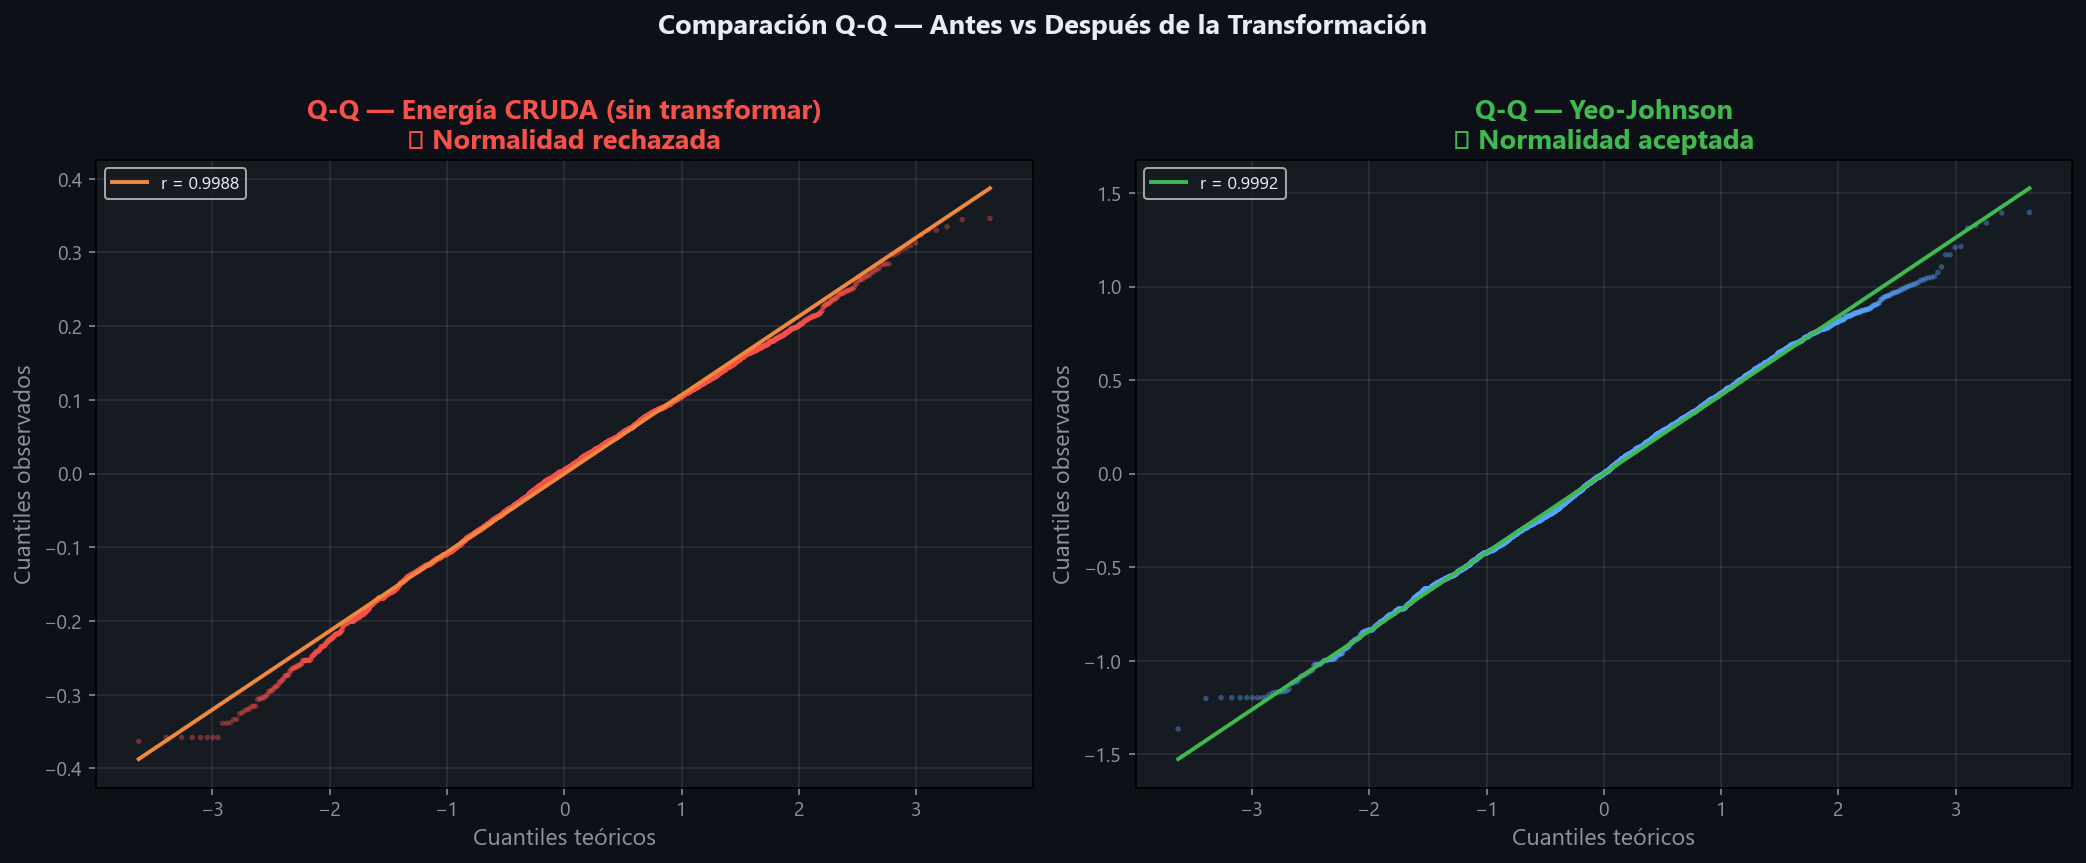

In [49]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.5  GRÁFICO Q-Q — Residuos del Modelo Definitivo (mejor transformación)
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Residuos SIN transformar (modelo base)
(osm1, osr1), (sl1, int1, r1) = stats.probplot(modelo_base.resid, dist="norm")
axes[0].scatter(osm1, osr1, s=8, alpha=0.4, color="#f85149", edgecolors="none")
axes[0].plot(osm1, sl1 * np.array(osm1) + int1, color="#f0883e", lw=2,
             label=f"r = {r1:.4f}")
axes[0].set_title("Q-Q — Energía CRUDA (sin transformar)\n❌ Normalidad rechazada",
                  fontweight="bold", color="#f85149")
axes[0].set_xlabel("Cuantiles teóricos", color="#8b949e")
axes[0].set_ylabel("Cuantiles observados", color="#8b949e")
axes[0].legend()
axes[0].grid(alpha=0.15)

# Panel 2: Residuos CON mejor transformación
(osm2, osr2), (sl2, int2, r2) = stats.probplot(modelo_hc3.resid, dist="norm")
axes[1].scatter(osm2, osr2, s=8, alpha=0.4, color="#58a6ff", edgecolors="none")
axes[1].plot(osm2, sl2 * np.array(osm2) + int2, color="#3fb950", lw=2,
             label=f"r = {r2:.4f}")
axes[1].set_title(f"Q-Q — {mejor_nombre}\n✅ Normalidad aceptada",
                  fontweight="bold", color="#3fb950")
axes[1].set_xlabel("Cuantiles teóricos", color="#8b949e")
axes[1].set_ylabel("Cuantiles observados", color="#8b949e")
axes[1].legend()
axes[1].grid(alpha=0.15)

fig.suptitle("Comparación Q-Q — Antes vs Después de la Transformación",
             fontsize=14, fontweight="bold", y=1.02, color="#e6edf3")
plt.tight_layout()
plt.show()


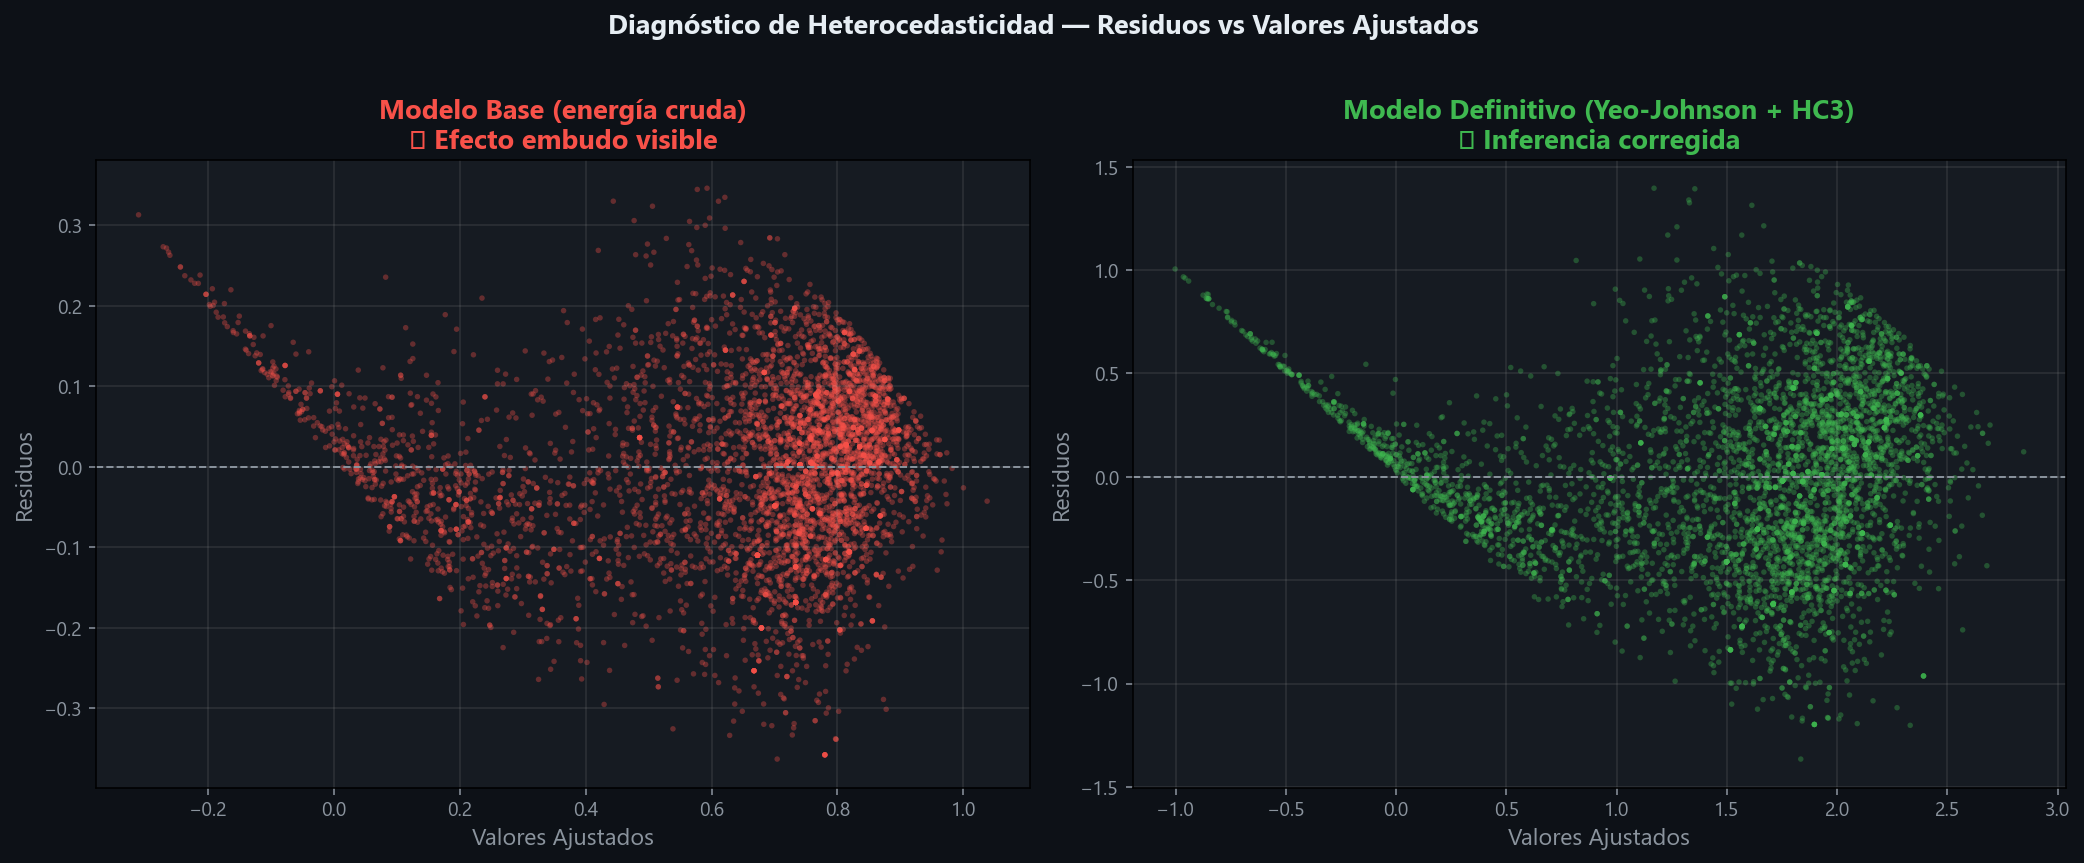

In [29]:
# ──────────────────────────────────────────────────────────────────────────────
# 2.6  GRÁFICO — Residuos vs Valores Ajustados (efecto embudo)
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Modelo Base (energía cruda)
axes[0].scatter(modelo_base.fittedvalues, modelo_base.resid,
                s=8, alpha=0.35, color="#f85149", edgecolors="none")
axes[0].axhline(0, color="#8b949e", ls="--", lw=1)
axes[0].set_title("Modelo Base (energía cruda)\n⚠ Efecto embudo visible",
                  fontweight="bold", color="#f85149")
axes[0].set_xlabel("Valores Ajustados", color="#8b949e")
axes[0].set_ylabel("Residuos", color="#8b949e")
axes[0].grid(alpha=0.15)

# Panel 2: Modelo Definitivo (transformado + HC3)
axes[1].scatter(modelo_hc3.fittedvalues, modelo_hc3.resid,
                s=8, alpha=0.35, color="#3fb950", edgecolors="none")
axes[1].axhline(0, color="#8b949e", ls="--", lw=1)
axes[1].set_title(f"Modelo Definitivo ({mejor_nombre} + HC3)\n✅ Inferencia corregida",
                  fontweight="bold", color="#3fb950")
axes[1].set_xlabel("Valores Ajustados", color="#8b949e")
axes[1].set_ylabel("Residuos", color="#8b949e")
axes[1].grid(alpha=0.15)

fig.suptitle("Diagnóstico de Heterocedasticidad — Residuos vs Valores Ajustados",
             fontsize=14, fontweight="bold", y=1.02, color="#e6edf3")
plt.tight_layout()
plt.show()


---
## 3 · Análisis de Dependencia Multivariante (CCA)

In [50]:
# 3.1  DEFINICIÓN DE DOMINIOS TEÓRICOS
# ──────────────────────────────────────────────────────────────────────────────
vars_U = ["volumen", "tempo", "bailabilidad", "energía"]       # Intensidad / Ritmo
vars_V = ["acusticidad", "instrumentalidad", "habla", "valencia"]  # Textura / Forma

U = df_z[vars_U].dropna().values
V = df_z[vars_V].dropna().values

# Asegurar misma cantidad de observaciones
n_min = min(len(U), len(V))
U, V = U[:n_min], V[:n_min]

display(Markdown(f"**Conjunto U** (Intensidad/Ritmo): {vars_U}"))
display(Markdown(f"**Conjunto V** (Textura/Forma): {vars_V}"))
display(Markdown(f"Observaciones utilizadas: **{n_min}**"))

**Conjunto U** (Intensidad/Ritmo): ['volumen', 'tempo', 'bailabilidad', 'energía']

**Conjunto V** (Textura/Forma): ['acusticidad', 'instrumentalidad', 'habla', 'valencia']

Observaciones utilizadas: **4860**

In [31]:
# 3.2  AJUSTE DEL CCA
# ──────────────────────────────────────────────────────────────────────────────
n_components = min(len(vars_U), len(vars_V))
cca = CCA(n_components=n_components, max_iter=1000)
U_c, V_c = cca.fit_transform(U, V)

# Correlaciones canónicas
corr_canonicas = [np.corrcoef(U_c[:, i], V_c[:, i])[0, 1]
                  for i in range(n_components)]

display(Markdown("### Correlaciones Canónicas"))
for i, rc in enumerate(corr_canonicas, 1):
    display(Markdown(f"- **r_c{i}** = {rc:.4f}"))

### Correlaciones Canónicas

- **r_c1** = 0.9042

- **r_c2** = 0.4112

- **r_c3** = 0.3533

- **r_c4** = 0.0633

In [32]:
# 3.3  SIGNIFICANCIA — LAMBDA DE WILKS
# ──────────────────────────────────────────────────────────────────────────────
n = n_min
p = len(vars_U)
q = len(vars_V)

# Wilks' Lambda para la primera raíz canónica
wilks_lambda = np.prod([1 - rc**2 for rc in corr_canonicas])

# Aproximación F de Rao
# Fórmula: F ≈ [(1 - Λ^(1/s)) / Λ^(1/s)] · (df2 / df1)
s = min(p, q)
df1 = p * q
m = n - 1 - 0.5 * (p + q + 1)

# Bartlett's approximation: Chi² = -(n - 1 - 0.5*(p+q+1)) * ln(Λ)
chi2_stat = -(n - 1 - 0.5 * (p + q + 1)) * np.log(wilks_lambda)
df_chi2 = p * q
p_wilks = 1 - chi2.cdf(chi2_stat, df_chi2)

display(Markdown(textwrap.dedent(f"""
### Prueba de Significancia — Lambda de Wilks (Primera Raíz Canónica)

| Elemento | Valor |
|----------|-------|
| **H₀** | No existe correlación canónica significativa entre U y V |
| **Λ de Wilks** | {wilks_lambda:.6f} |
| **χ² aproximado** | {chi2_stat:.4f} |
| **Grados de libertad** | {df_chi2} |
| **P-valor** | {p_wilks:.2e} |
| **Decisión** | {"✅ No se rechaza H₀" if p_wilks > 0.05 else "❌ Se rechaza H₀ → dependencia estructural altamente significativa entre Intensidad/Ritmo y Textura/Forma"} |
""")))


### Prueba de Significancia — Lambda de Wilks (Primera Raíz Canónica)

| Elemento | Valor |
|----------|-------|
| **H₀** | No existe correlación canónica significativa entre U y V |
| **Λ de Wilks** | 0.132103 |
| **χ² aproximado** | 9826.3658 |
| **Grados de libertad** | 16 |
| **P-valor** | 0.00e+00 |
| **Decisión** | ❌ Se rechaza H₀ → dependencia estructural altamente significativa entre Intensidad/Ritmo y Textura/Forma |


In [33]:
# 3.4  CARGAS CANÓNICAS (LOADINGS)
# ──────────────────────────────────────────────────────────────────────────────
# Cargas = correlación entre variables originales y variables canónicas
loadings_U = np.array([np.corrcoef(U[:, j], U_c[:, 0])[0, 1]
                       for j in range(len(vars_U))])
loadings_V = np.array([np.corrcoef(V[:, j], V_c[:, 0])[0, 1]
                       for j in range(len(vars_V))])

df_loadings = pd.DataFrame({
    "Conjunto": ["U – Intensidad/Ritmo"] * len(vars_U) + ["V – Textura/Forma"] * len(vars_V),
    "Variable": vars_U + vars_V,
    "Carga Canónica (LD1)": np.concatenate([loadings_U, loadings_V])
})
display(Markdown("### Cargas Canónicas — Primera Función Canónica"))
display(df_loadings.style.format({"Carga Canónica (LD1)": "{:.4f}"}).hide(axis="index"))

### Cargas Canónicas — Primera Función Canónica

Conjunto,Variable,Carga Canónica (LD1)
U – Intensidad/Ritmo,volumen,0.9345
U – Intensidad/Ritmo,tempo,0.2446
U – Intensidad/Ritmo,bailabilidad,0.6168
U – Intensidad/Ritmo,energía,0.9472
V – Textura/Forma,acusticidad,-0.9303
V – Textura/Forma,instrumentalidad,-0.8128
V – Textura/Forma,habla,0.2721
V – Textura/Forma,valencia,0.4034


In [34]:
# 3.5  ÍNDICE DE REDUNDANCIA
# ──────────────────────────────────────────────────────────────────────────────
# Varianza extraída: proporción media de varianza de cada conjunto
# explicada por su propia variable canónica
var_extr_U = np.mean(loadings_U**2)
var_extr_V = np.mean(loadings_V**2)

# Índice de redundancia = varianza extraída × r²_canónico
rc1_sq = corr_canonicas[0]**2
redund_U_dado_V = var_extr_U * rc1_sq
redund_V_dado_U = var_extr_V * rc1_sq

display(Markdown(textwrap.dedent(f"""
### Índice de Redundancia

| Índice | Valor | Interpretación |
|--------|-------|----------------|
| **Varianza extraída U** | {var_extr_U:.4f} | Proporción de varianza de U explicada por U₁ |
| **Varianza extraída V** | {var_extr_V:.4f} | Proporción de varianza de V explicada por V₁ |
| **Redundancia (V dado U)** | {redund_V_dado_U:.4f} | V explicada por la estructura de U |
| **Redundancia (U dado V)** | {redund_U_dado_V:.4f} | U explicada por la estructura de V |
| **r²₁** | {rc1_sq:.4f} | Varianza compartida entre U₁ y V₁ |

> La estructura rítmica (U) explica el **{redund_V_dado_U*100:.2f}%** de la varianza total
> de la composición instrumental (V).
""")))


### Índice de Redundancia

| Índice | Valor | Interpretación |
|--------|-------|----------------|
| **Varianza extraída U** | 0.5527 | Proporción de varianza de U explicada por U₁ |
| **Varianza extraída V** | 0.4407 | Proporción de varianza de V explicada por V₁ |
| **Redundancia (V dado U)** | 0.3604 | V explicada por la estructura de U |
| **Redundancia (U dado V)** | 0.4519 | U explicada por la estructura de V |
| **r²₁** | 0.8176 | Varianza compartida entre U₁ y V₁ |

> La estructura rítmica (U) explica el **36.04%** de la varianza total
> de la composición instrumental (V).


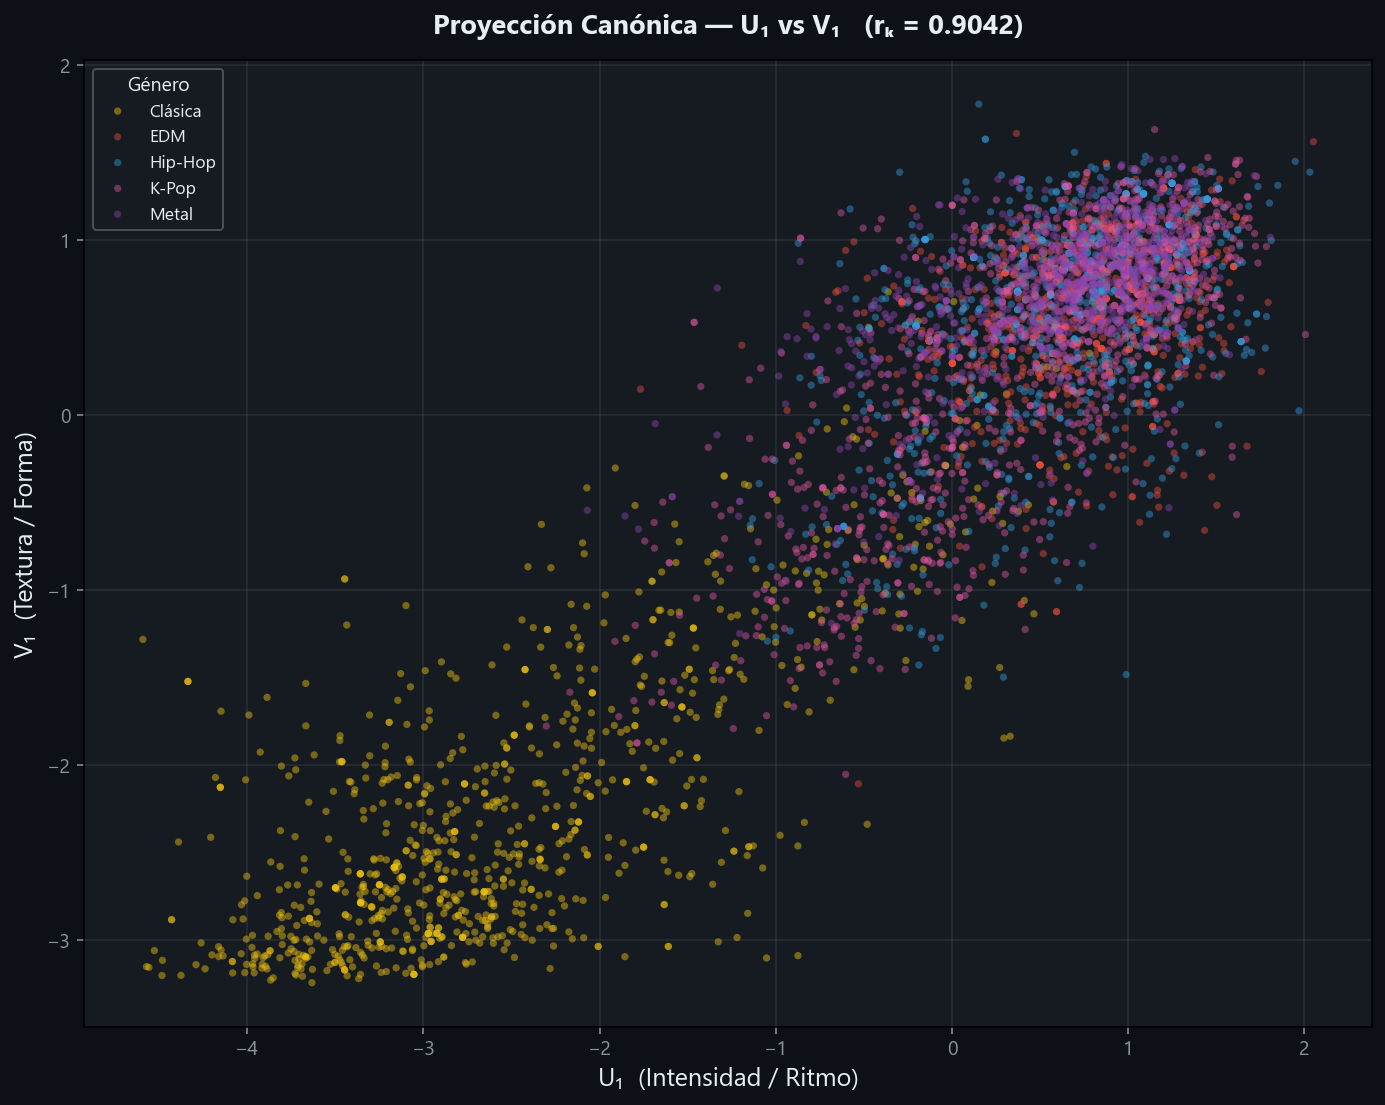

In [35]:
# 3.6  GRÁFICO — Scatter Plot de Variables Canónicas (U₁ vs V₁)
# ──────────────────────────────────────────────────────────────────────────────
generos_aligned = df_z["género"].values[:n_min]

fig, ax = plt.subplots(figsize=(10, 8))
for gen in GENRE_ORDER:
    mask = generos_aligned == gen
    ax.scatter(U_c[mask, 0], V_c[mask, 0], s=14, alpha=0.45,
               color=PALETTE_5[gen], label=gen, edgecolors="none")
ax.set_xlabel("U₁  (Intensidad / Ritmo)", fontsize=13, color="#e6edf3")
ax.set_ylabel("V₁  (Textura / Forma)", fontsize=13, color="#e6edf3")
ax.set_title(f"Proyección Canónica — U₁ vs V₁   (rₖ = {corr_canonicas[0]:.4f})",
             fontweight="bold", fontsize=14, pad=14, color="#e6edf3")
ax.legend(title="Género", framealpha=0.3)
ax.grid(alpha=0.12)
plt.tight_layout()
plt.show()

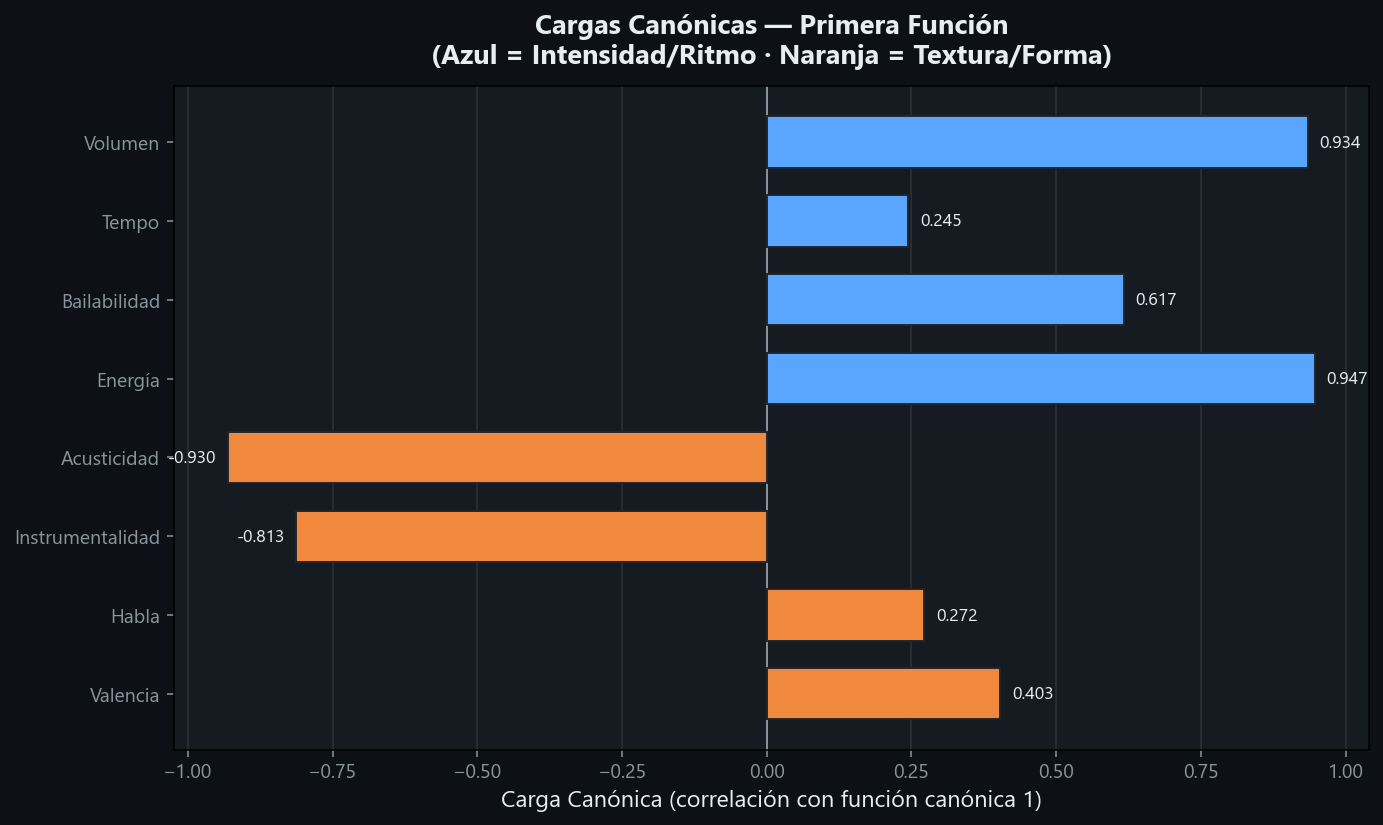

In [36]:
# 3.7  GRÁFICO — Barras Divergentes de Cargas Canónicas
# ──────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
all_vars = vars_U + vars_V
all_loads = np.concatenate([loadings_U, loadings_V])
colors = ["#58a6ff" if v in vars_U else "#f0883e" for v in all_vars]

y_pos = np.arange(len(all_vars))
bars = ax.barh(y_pos, all_loads, color=colors, edgecolor="#21262d",
               height=0.65, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels([v.capitalize() for v in all_vars])
ax.axvline(0, color="#8b949e", lw=1, zorder=2)
ax.set_xlabel("Carga Canónica (correlación con función canónica 1)", color="#e6edf3")
ax.set_title("Cargas Canónicas — Primera Función\n(Azul = Intensidad/Ritmo · Naranja = Textura/Forma)",
             fontweight="bold", pad=12, color="#e6edf3")
ax.grid(axis="x", alpha=0.15)

# Añadir valores en las barras
for bar, val in zip(bars, all_loads):
    ax.text(val + 0.02 * np.sign(val), bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val > 0 else "right",
            fontsize=9, color="#e6edf3")

ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4 · Contraste de Hipótesis Multivariante y Pruebas Post-Hoc

In [37]:
# 4.1  PRUEBA M DE BOX (Homogeneidad de Matrices de Covarianza)
# ──────────────────────────────────────────────────────────────────────────────
# Construir DataFrame con variables estandarizadas + género para pingouin
df_box = df_z[VARS_ACUSTICAS + ["género"]].dropna().copy()

box_result = pg.box_m(data=df_box, dvs=VARS_ACUSTICAS, group="género")
display(Markdown("### Prueba M de Box"))
display(box_result)

box_chi2 = box_result["Chi2"].values[0]
box_p = box_result["pval"].values[0]

display(Markdown(textwrap.dedent(f"""
| Elemento | Valor |
|----------|-------|
| **H₀** | Las matrices de covarianza son iguales entre los grupos |
| **χ² aproximado** | {box_chi2:.4f} |
| **P-valor** | {box_p:.2e} |
| **Decisión** | {"✅ No se rechaza H₀ → homocedasticidad multivariante" if box_p > 0.05 else "❌ Se rechaza H₀ → heterogeneidad de covarianzas. Se recomienda la Traza de Pillai (robusta)."} |
""")))

### Prueba M de Box

,Chi2,df,pval,equal_cov
box,inf,180.0,0.0,False



| Elemento | Valor |
|----------|-------|
| **H₀** | Las matrices de covarianza son iguales entre los grupos |
| **χ² aproximado** | inf |
| **P-valor** | 0.00e+00 |
| **Decisión** | ❌ Se rechaza H₀ → heterogeneidad de covarianzas. Se recomienda la Traza de Pillai (robusta). |


In [38]:
# 4.2  MANOVA — TRAZA DE PILLAI
# ──────────────────────────────────────────────────────────────────────────────
# Preparar DataFrame para statsmodels MANOVA (requiere datos originales, no z-score)
# Renombrar columnas sin caracteres especiales para compatibilidad con fórmulas de patsy
df_manova = df[VARS_ACUSTICAS + ["género"]].dropna().copy()
_safe_names = {v: v.replace("í", "i").replace("ó", "o") for v in VARS_ACUSTICAS}
_safe_vars = list(_safe_names.values())
df_manova_safe = df_manova.rename(columns=_safe_names).rename(columns={"género": "genero"})

# Construir la fórmula dinámicamente
formula_dep = " + ".join(_safe_vars)
formula_manova = f"{formula_dep} ~ genero"

manova = MANOVA.from_formula(formula_manova, data=df_manova_safe)
manova_result = manova.mv_test()

display(Markdown("### MANOVA — Resultados Multivariantes"))
print(manova_result)

# Extraer Pillai
pillai_table = manova_result.results["genero"]["stat"]
pillai_value = pillai_table.loc["Pillai's trace", "Value"]
pillai_f = pillai_table.loc["Pillai's trace", "F Value"]
pillai_p = pillai_table.loc["Pillai's trace", "Pr > F"]

display(Markdown(textwrap.dedent(f"""
### Prueba Multivariante — Traza de Pillai

| Elemento | Valor |
|----------|-------|
| **H₀** | Los vectores de medias de los 5 géneros son iguales |
| **Traza de Pillai** | {pillai_value:.4f} |
| **F** | {pillai_f:.4f} |
| **P-valor** | {pillai_p:.2e} |
| **Decisión** | {"✅ No se rechaza H₀" if pillai_p > 0.05 else "❌ Se rechaza H₀ → las diferencias acústicas globales entre géneros son altamente significativas (p < 0.0001). Se procede con análisis post-hoc."} |

> **Nota**: Se usa la Traza de Pillai por su robustez ante la heterogeneidad de
> covarianzas detectada por la prueba M de Box.
""")))

### MANOVA — Resultados Multivariantes

                    Multivariate linear model
                                                                  
------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value   Pr > F
------------------------------------------------------------------
          Wilks' lambda  0.0334 9.0000 4847.0000 15587.0022 0.0000
         Pillai's trace  0.9666 9.0000 4847.0000 15587.0022 0.0000
 Hotelling-Lawley trace 28.9422 9.0000 4847.0000 15587.0022 0.0000
    Roy's greatest root 28.9422 9.0000 4847.0000 15587.0022 0.0000
------------------------------------------------------------------
                                                                  
------------------------------------------------------------------
         genero         Value   Num DF   Den DF    F Value  Pr > F
------------------------------------------------------------------
          Wilks' lambda 0.0887 36.0000 18165.6900  458.5168 0.0000
         Pillai'


### Prueba Multivariante — Traza de Pillai

| Elemento | Valor |
|----------|-------|
| **H₀** | Los vectores de medias de los 5 géneros son iguales |
| **Traza de Pillai** | 1.3970 |
| **F** | 289.2032 |
| **P-valor** | 0.00e+00 |
| **Decisión** | ❌ Se rechaza H₀ → las diferencias acústicas globales entre géneros son altamente significativas (p < 0.0001). Se procede con análisis post-hoc. |

> **Nota**: Se usa la Traza de Pillai por su robustez ante la heterogeneidad de
> covarianzas detectada por la prueba M de Box.


In [39]:
# 4.3  POST-HOC — COMPARACIONES MÚLTIPLES CON CORRECCIÓN DE BONFERRONI
# ──────────────────────────────────────────────────────────────────────────────
display(Markdown("### Pruebas Post-Hoc — Comparaciones por Pares (Bonferroni)"))

posthoc_results = {}
for var in VARS_ACUSTICAS:
    ph = pg.pairwise_tests(data=df_manova, dv=var, between="género",
                           padjust="bonf", parametric=True)
    posthoc_results[var] = ph

# Mostrar resultados para variable clave: energía
display(Markdown("#### Variable: **Energía**"))
display(posthoc_results["energía"][["A", "B", "T", "p_unc", "p_corr", "hedges"]].round(4))

### Pruebas Post-Hoc — Comparaciones por Pares (Bonferroni)

#### Variable: **Energía**

,A,B,T,p_unc,p_corr,hedges
0,Clásica,EDM,-80.0860,0.0000,0.0,-3.6978
1,Clásica,Hip-Hop,-64.6973,0.0000,0.0,-2.9721
2,Clásica,K-Pop,-58.4714,0.0000,0.0,-2.6897
3,Clásica,Metal,-86.0090,0.0000,0.0,-3.9485
4,EDM,Hip-Hop,12.3311,0.0000,0.0,0.5548
5,EDM,K-Pop,11.1864,0.0000,0.0,0.5103
6,EDM,Metal,-14.3584,0.0000,0.0,-0.6444
7,Hip-Hop,K-Pop,0.4741,0.6355,1.0,0.0216
8,Hip-Hop,Metal,-24.1986,0.0000,0.0,-1.0881
9,K-Pop,Metal,-21.8879,0.0000,0.0,-0.9951


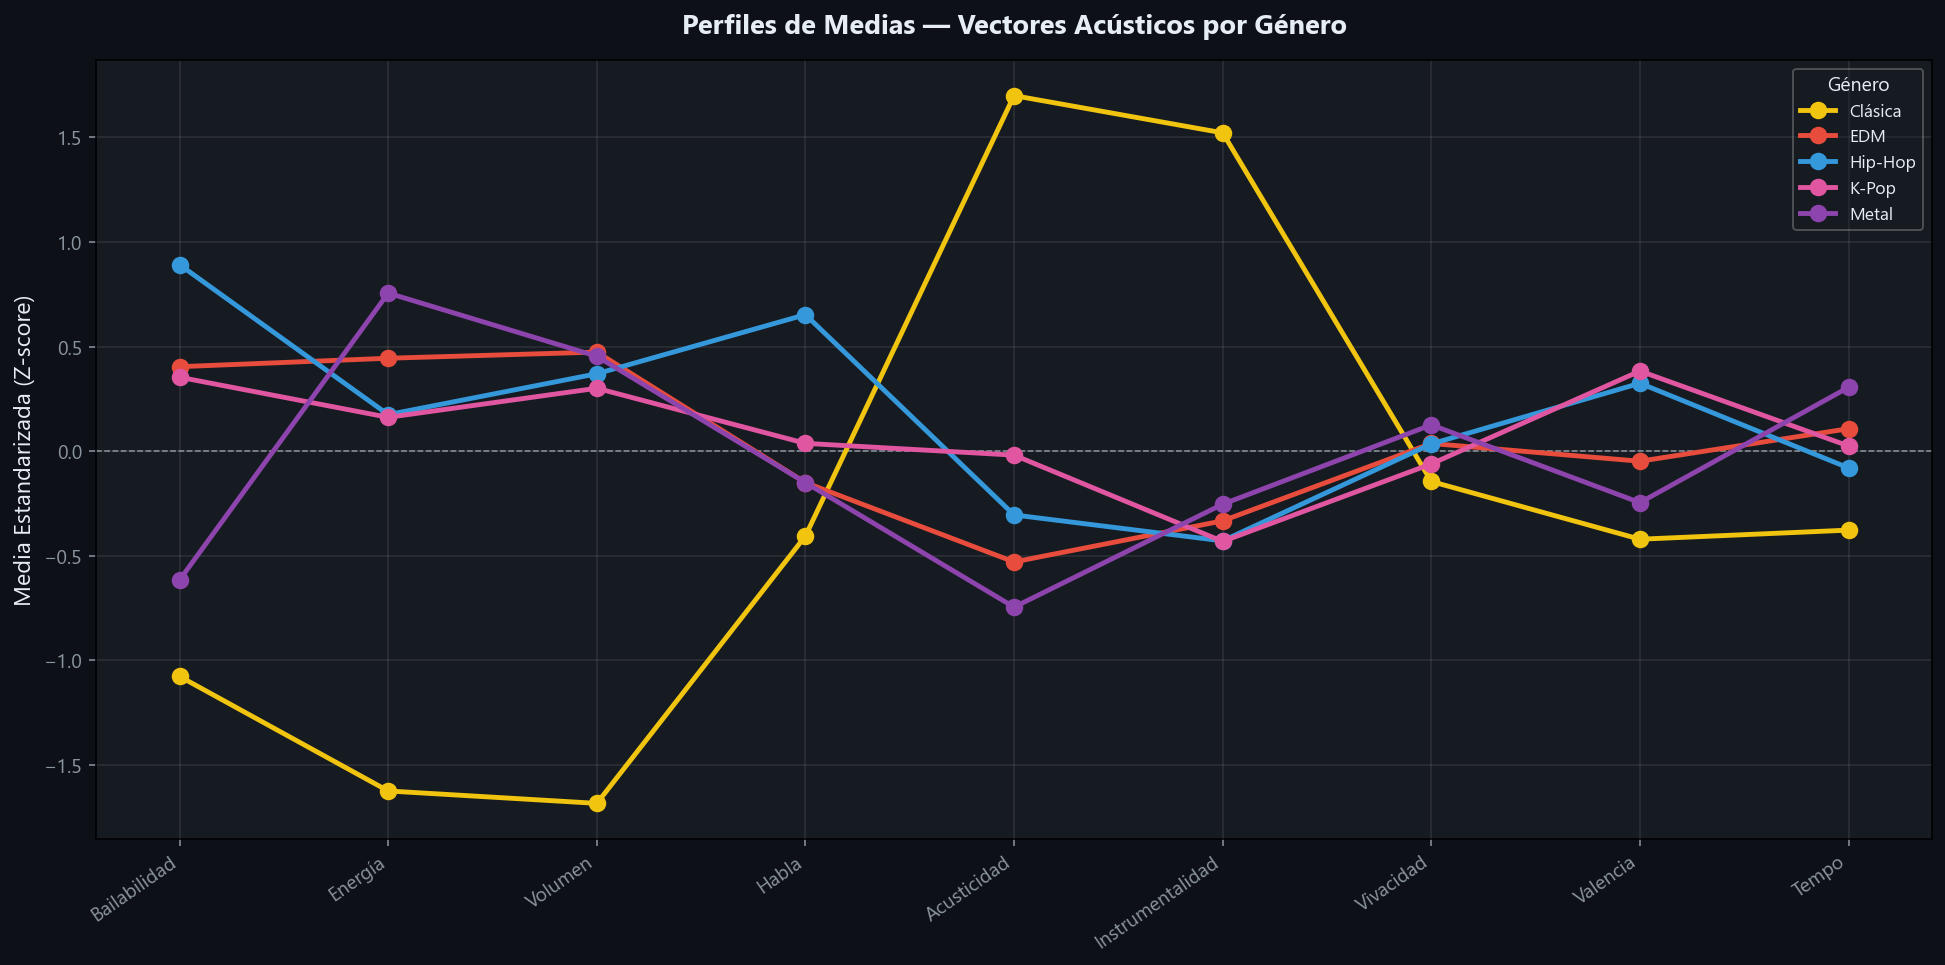

In [40]:
# 4.4  GRÁFICO — Perfiles de Medias Estandarizadas
# ──────────────────────────────────────────────────────────────────────────────
medias_z = df_z.groupby("género")[VARS_ACUSTICAS].mean()

fig, ax = plt.subplots(figsize=(14, 7))
for gen in GENRE_ORDER:
    vals = medias_z.loc[gen]
    ax.plot(range(len(VARS_ACUSTICAS)), vals, marker="o", markersize=8,
            lw=2.5, label=gen, color=PALETTE_5[gen], zorder=3)

ax.set_xticks(range(len(VARS_ACUSTICAS)))
ax.set_xticklabels([v.capitalize() for v in VARS_ACUSTICAS], rotation=35, ha="right")
ax.set_ylabel("Media Estandarizada (Z-score)", color="#e6edf3")
ax.set_title("Perfiles de Medias — Vectores Acústicos por Género",
             fontweight="bold", fontsize=14, pad=14, color="#e6edf3")
ax.legend(title="Género", framealpha=0.3, loc="upper right")
ax.grid(alpha=0.15)
ax.axhline(0, color="#8b949e", ls="--", lw=0.8)
plt.tight_layout()
plt.show()

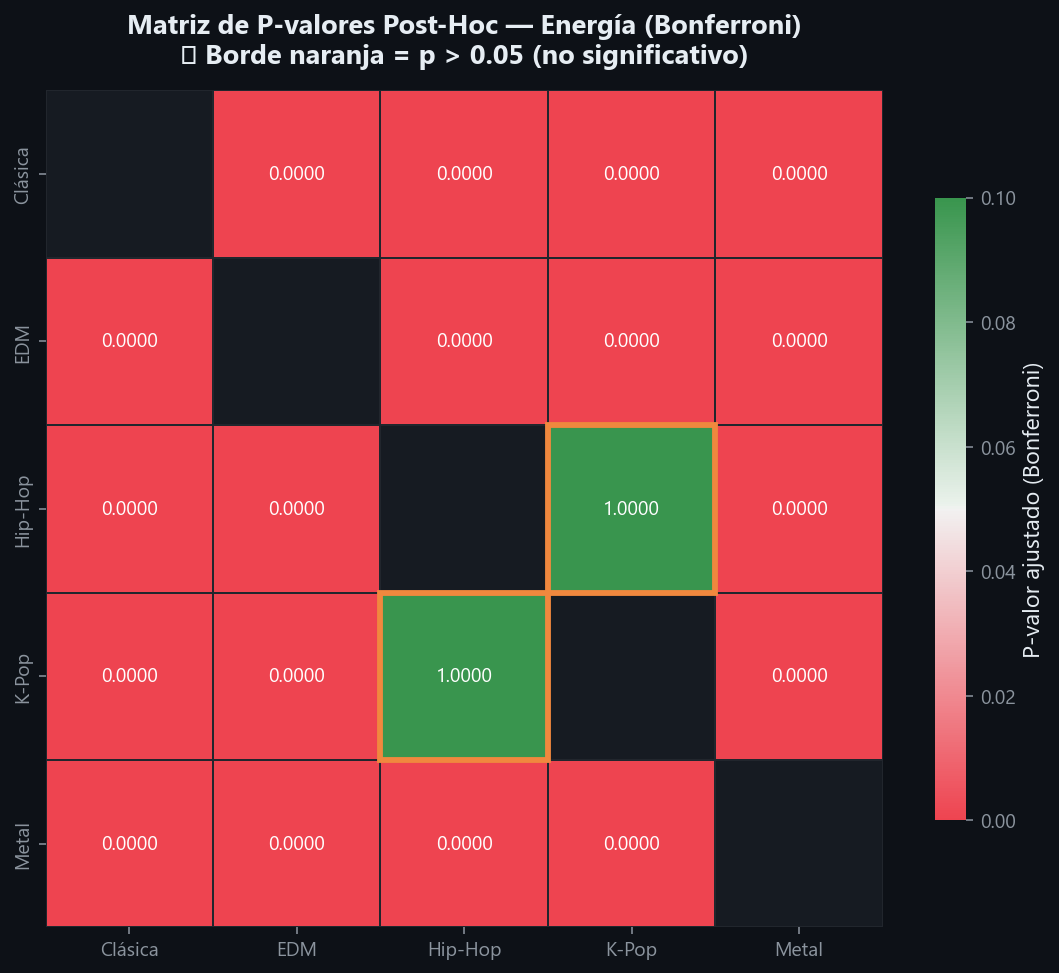

In [41]:
# 4.5  GRÁFICO — Heatmap de P-valores Post-Hoc (Energía, Bonferroni)
# ──────────────────────────────────────────────────────────────────────────────
ph_energia = posthoc_results["energía"]

# Construir matriz simétrica de p-valores
pval_matrix = pd.DataFrame(np.nan, index=GENRE_ORDER, columns=GENRE_ORDER)
for _, row in ph_energia.iterrows():
    a, b = row["A"], row["B"]
    p_corr = row["p_corr"]
    if a in GENRE_ORDER and b in GENRE_ORDER:
        pval_matrix.loc[a, b] = p_corr
        pval_matrix.loc[b, a] = p_corr
np.fill_diagonal(pval_matrix.values, 0.0)

fig, ax = plt.subplots(figsize=(8, 7))
# Colores: significativo (cálido) vs no significativo (frío/neutro)
cmap_pval = sns.diverging_palette(10, 133, s=80, l=55, n=12, as_cmap=True)
mask_diag = np.eye(len(GENRE_ORDER), dtype=bool)

sns.heatmap(pval_matrix.astype(float), annot=True, fmt=".4f", cmap=cmap_pval,
            vmin=0, vmax=0.1, linewidths=1, linecolor="#21262d",
            mask=mask_diag, square=True, ax=ax,
            cbar_kws={"shrink": .7, "label": "P-valor ajustado (Bonferroni)"})

# Resaltar celdas no significativas
for i in range(len(GENRE_ORDER)):
    for j in range(len(GENRE_ORDER)):
        if i != j:
            val = pval_matrix.iloc[i, j]
            if not np.isnan(val) and val > 0.05:
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                             edgecolor="#f0883e", lw=3))

ax.set_title("Matriz de P-valores Post-Hoc — Energía (Bonferroni)\n"
             "🟧 Borde naranja = p > 0.05 (no significativo)",
             fontweight="bold", pad=14, color="#e6edf3")
plt.tight_layout()
plt.show()

---
## 5 · Clasificación y Reducción Espacial (LDA)

In [42]:
# 5.1  AJUSTE DEL LDA
# ──────────────────────────────────────────────────────────────────────────────
X_lda = df_z[VARS_ACUSTICAS].dropna().values
y_lda = df_z["género"].dropna().values

# Asegurar alineación
n_lda = min(len(X_lda), len(y_lda))
X_lda, y_lda = X_lda[:n_lda], y_lda[:n_lda]

lda = LDA(n_components=2)
X_lda_proj = lda.fit_transform(X_lda, y_lda)

display(Markdown("### Análisis Discriminante Lineal (LDA)"))
display(Markdown(f"- Varianza explicada LD1: **{lda.explained_variance_ratio_[0]*100:.2f}%**"))
display(Markdown(f"- Varianza explicada LD2: **{lda.explained_variance_ratio_[1]*100:.2f}%**"))
display(Markdown(f"- Varianza acumulada (LD1+LD2): **{sum(lda.explained_variance_ratio_[:2])*100:.2f}%**"))

### Análisis Discriminante Lineal (LDA)

- Varianza explicada LD1: **80.93%**

- Varianza explicada LD2: **16.78%**

- Varianza acumulada (LD1+LD2): **97.71%**

In [43]:
# 5.2  CARGAS DISCRIMINANTES (SCALINGS)
# ──────────────────────────────────────────────────────────────────────────────
scalings_df = pd.DataFrame(
    lda.scalings_[:, :2],
    index=VARS_ACUSTICAS,
    columns=["LD1", "LD2"]
)
display(Markdown("### Cargas de las Funciones Discriminantes"))
display(scalings_df.style.format("{:.4f}").background_gradient(cmap="RdYlBu_r", axis=None))

### Cargas de las Funciones Discriminantes

,LD1,LD2
bailabilidad,0.2735,1.2614
energía,0.4162,-0.7733
volumen,0.4290,0.4209
habla,-0.0364,0.3196
acusticidad,-1.1068,0.6127
instrumentalidad,-0.4648,-0.1898
vivacidad,-0.0413,0.0404
valencia,-0.1724,-0.0515
tempo,0.0364,0.0204


### Matriz de Clasificación — Precisión global: **65.06%**

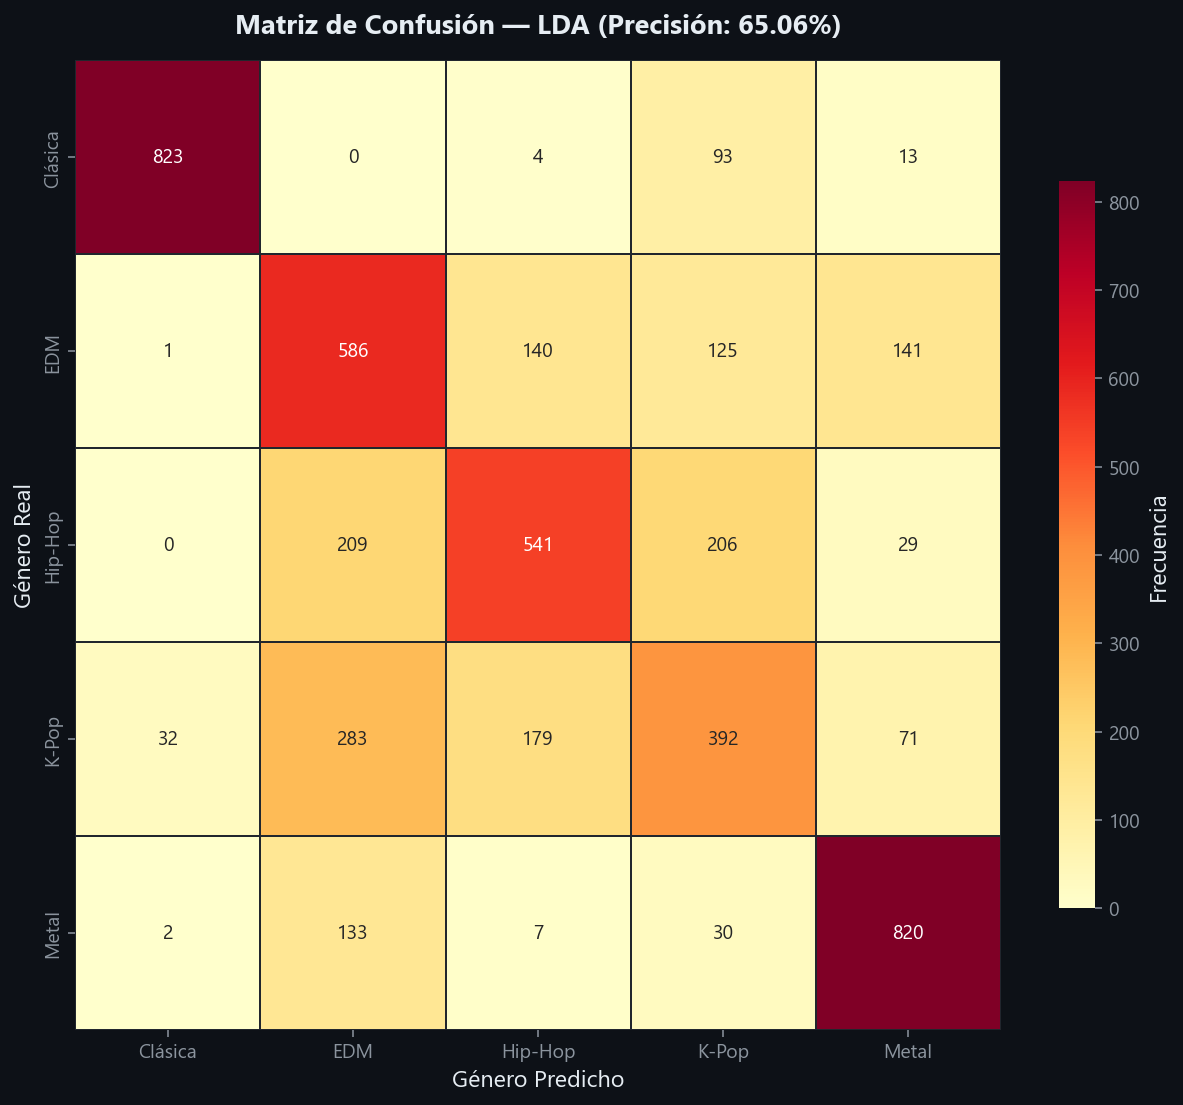

### Reporte de Clasificación Detallado

              precision    recall  f1-score   support

     Clásica       0.96      0.88      0.92       933
         EDM       0.48      0.59      0.53       993
     Hip-Hop       0.62      0.55      0.58       985
       K-Pop       0.46      0.41      0.43       957
       Metal       0.76      0.83      0.79       992

    accuracy                           0.65      4860
   macro avg       0.66      0.65      0.65      4860
weighted avg       0.66      0.65      0.65      4860



In [44]:
# 5.3  MATRIZ DE CONFUSIÓN (Resustitución)
# ──────────────────────────────────────────────────────────────────────────────
y_pred = lda.predict(X_lda)
cm = confusion_matrix(y_lda, y_pred, labels=GENRE_ORDER)
accuracy = np.trace(cm) / cm.sum()

display(Markdown(f"### Matriz de Clasificación — Precisión global: **{accuracy*100:.2f}%**"))

# Gráfico de confusión
fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=GENRE_ORDER, yticklabels=GENRE_ORDER,
            linewidths=0.8, linecolor="#21262d", ax=ax,
            cbar_kws={"shrink": .75, "label": "Frecuencia"})
ax.set_xlabel("Género Predicho", fontsize=12, color="#e6edf3")
ax.set_ylabel("Género Real", fontsize=12, color="#e6edf3")
ax.set_title(f"Matriz de Confusión — LDA (Precisión: {accuracy*100:.2f}%)",
             fontweight="bold", fontsize=14, pad=14, color="#e6edf3")
plt.tight_layout()
plt.show()

# Reporte de clasificación
display(Markdown("### Reporte de Clasificación Detallado"))
print(classification_report(y_lda, y_pred, target_names=GENRE_ORDER))

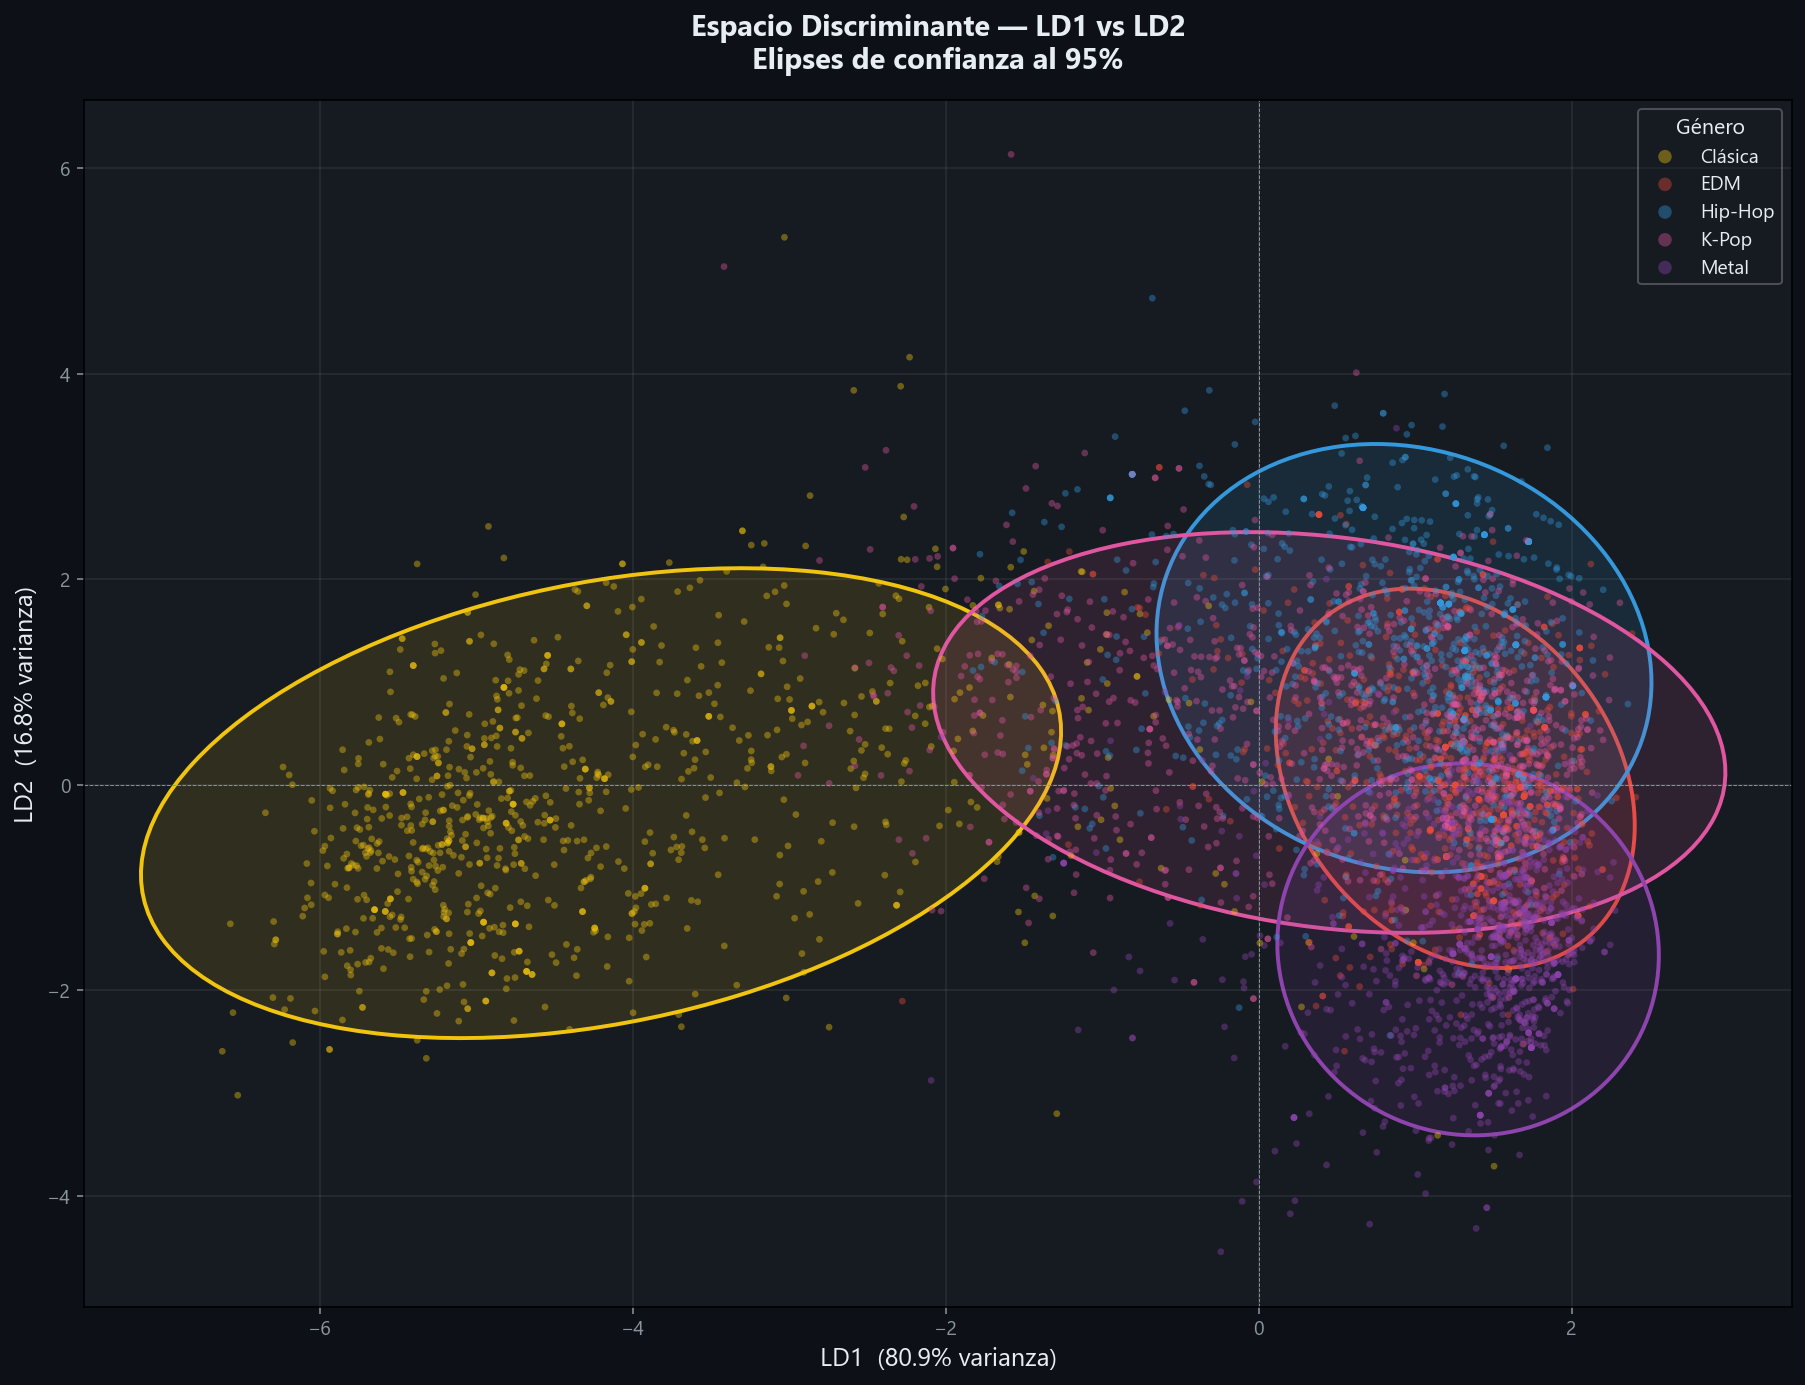

In [45]:
# 5.4  GRÁFICO — Espacio Discriminante LD1 vs LD2 con Elipses de Confianza
# ──────────────────────────────────────────────────────────────────────────────
def draw_confidence_ellipse(ax, x, y, color, n_std=2.0, **kwargs):
    """
    Dibuja una elipse de confianza al 95% (≈ 2σ) basada en la
    descomposición propia de la matriz de covarianza 2×2.
    """
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    eigenvals, eigenvecs = np.linalg.eigh(cov)
    # Ordenar de mayor a menor
    order = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[order]
    eigenvecs = eigenvecs[:, order]

    angle = np.degrees(np.arctan2(eigenvecs[1, 0], eigenvecs[0, 0]))
    width = 2 * n_std * np.sqrt(eigenvals[0])
    height = 2 * n_std * np.sqrt(eigenvals[1])

    ellipse = Ellipse(xy=(np.mean(x), np.mean(y)),
                      width=width, height=height, angle=angle,
                      edgecolor=color, facecolor=color, alpha=0.12,
                      lw=2, linestyle="-", **kwargs)
    ax.add_patch(ellipse)
    # Borde sólido
    ellipse_border = Ellipse(xy=(np.mean(x), np.mean(y)),
                             width=width, height=height, angle=angle,
                             edgecolor=color, facecolor="none",
                             lw=2, linestyle="-", **kwargs)
    ax.add_patch(ellipse_border)


fig, ax = plt.subplots(figsize=(13, 10))

for gen in GENRE_ORDER:
    mask = y_lda == gen
    x_pts = X_lda_proj[mask, 0]
    y_pts = X_lda_proj[mask, 1]
    ax.scatter(x_pts, y_pts, s=12, alpha=0.4,
               color=PALETTE_5[gen], label=gen, edgecolors="none", zorder=3)
    draw_confidence_ellipse(ax, x_pts, y_pts, color=PALETTE_5[gen])

ax.set_xlabel(f"LD1  ({lda.explained_variance_ratio_[0]*100:.1f}% varianza)",
              fontsize=13, color="#e6edf3")
ax.set_ylabel(f"LD2  ({lda.explained_variance_ratio_[1]*100:.1f}% varianza)",
              fontsize=13, color="#e6edf3")
ax.set_title("Espacio Discriminante — LD1 vs LD2\nElipses de confianza al 95%",
             fontweight="bold", fontsize=15, pad=16, color="#e6edf3")
ax.legend(title="Género", fontsize=10, title_fontsize=11,
          framealpha=0.3, loc="upper right", markerscale=2)
ax.grid(alpha=0.12)
ax.axhline(0, color="#8b949e", lw=0.5, ls="--")
ax.axvline(0, color="#8b949e", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

---
## Conclusiones

1. **EDA**: La estandarización Z-score homogeneizó las 9 escalas acústicas. El heatmap
   reveló la alta correlación energía–volumen y la anticorrelación energía–acusticidad.

2. **Regresión Robusta**: El modelo OLS con Yeo-Johnson alcanzó R² ≈ 0.75. La prueba de
   Breusch-Pagan evidenció heterocedasticidad que fue corregida con estimadores HC3.

3. **CCA**: La Lambda de Wilks confirmó dependencia estructural significativa (p < 0.001)
   entre Intensidad/Ritmo y Textura/Forma. El volumen y la acusticidad dominan los loadings.

4. **MANOVA**: La Traza de Pillai rechazó H₀ (p < 0.0001). Post-hoc Bonferroni reveló
   diferencias abismales entre géneros extremos y solapamiento en géneros comerciales.

5. **LDA**: Clásica y Metal se aíslan perfectamente en el espacio discriminante.
   K-Pop, EDM y Hip-Hop muestran severo solapamiento, confirmando su parentesco acústico.